# Notebook hoạt động: Hồi quy tuyến tính nâng cao (Advanced Linear Regression)

Notebook này hỗ trợ chuỗi hoạt động về **chọn biến (feature selection)**, **chính quy hóa (regularization)** và **suy luận thống kê (statistical inference)** trong hồi quy tuyến tính.

Sinh viên sẽ so sánh:

1. Hồi quy bình phương tối thiểu thông thường đầy đủ (Ordinary Least Squares - OLS)
2. Chọn biến lùi theo giá trị p (backward selection using p-values)
3. Chọn biến tiến theo giá trị p (forward selection using p-values)
4. Hồi quy Ridge (Ridge regression)
5. Hồi quy Lasso (Least Absolute Shrinkage and Selection Operator - Lasso regression)
6. Độ bất định bằng bootstrap cho mô hình có phạt (penalized models)

Dữ liệu là dữ liệu tổng hợp (synthetic data), nên giảng viên có thể kiểm tra phương pháp nào tìm lại đúng các biến thật sự có tác động.

## Bảng thuật ngữ nhanh

| Tiếng Việt | English term | Ý nghĩa ngắn |
|---|---|---|
| Hồi quy tuyến tính | Linear regression | Mô hình dự đoán biến liên tục bằng tổ hợp tuyến tính của biến đầu vào |
| Bình phương tối thiểu thông thường | Ordinary Least Squares - OLS | Ước lượng hệ số bằng cách tối thiểu hóa tổng bình phương phần dư |
| Tổng bình phương phần dư | Residual Sum of Squares - RSS | Tổng của $(y_i-\hat y_i)^2$ |
| Hệ số hồi quy | Regression coefficient | Mức thay đổi trung bình của $y$ khi biến $x_j$ tăng 1 đơn vị, giữ các biến khác không đổi |
| Giá trị p | p-value | Mức bằng chứng chống lại giả thuyết hệ số bằng 0 |
| Chọn biến lùi | Backward selection | Bắt đầu với tất cả biến rồi loại dần biến có giá trị p lớn |
| Chọn biến tiến | Forward selection | Bắt đầu không có biến rồi thêm dần biến có giá trị p nhỏ |
| Chính quy hóa | Regularization | Thêm hình phạt vào hàm mất mát để giảm quá khớp |
| Co rút hệ số | Coefficient shrinkage | Làm hệ số nhỏ lại để mô hình ổn định hơn |
| Kiểm định chéo | Cross-validation | Chia dữ liệu nhiều lần để chọn siêu tham số và đánh giá mô hình |
| Bootstrap | Bootstrapping | Lấy mẫu lặp có hoàn lại để ước lượng độ bất định |


## Ký hiệu chính

Với vector đáp ứng $y$ và ma trận thiết kế $X$, hồi quy OLS ước lượng:

$$
\hat{\beta} = (X^T X)^{-1}X^T y
$$

Tổng bình phương phần dư (Residual Sum of Squares - RSS):

$$
RSS = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

Ridge và Lasso thêm hình phạt vào mục tiêu OLS:

$$
\text{Ridge: } RSS + \lambda \sum_{j=1}^{p}\beta_j^2
$$

$$
\text{Lasso: } RSS + \lambda \sum_{j=1}^{p}|\beta_j|
$$

Cách nhớ: **OLS ước lượng hệ số**, **chọn biến từng bước thêm/bớt biến**, **Ridge co rút hệ số**, còn **Lasso có thể đưa một số hệ số về đúng 0**.

In [1]:
# Core packages
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Make plots readable
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 10

# Locate project directory whether the notebook is opened from the root or notebooks/ folder.
CWD = Path.cwd()
if (CWD / "datasets").exists():
    PROJECT_DIR = CWD
elif (CWD.parent / "datasets").exists():
    PROJECT_DIR = CWD.parent

DATA_DIR = PROJECT_DIR / "datasets"
DATA_DIR

WindowsPath('C:/Users/Khiem Nguyen/Dropbox/Dropbox/Work/EIU/TEACHING/OlpAI/Hoạt động thực thành/Thực hành 4/v1/datasets')

In [2]:
def prepare_xy(df, target):
    """
    Convert a raw dataframe into a numeric design matrix X and response vector y.

    Mathematical idea:
    - The linear regression model expects a numeric matrix X.
    - Categorical variables are converted into dummy/one-hot variables.
    - drop_first=True avoids the dummy variable trap, where one dummy column is a linear
      combination of the others plus the intercept.
    """
    y = df[target].astype(float)
    X_raw = df.drop(columns=[target])
    X = pd.get_dummies(X_raw, drop_first=True, dtype=float)
    return X, y


def fit_ols(X, y):
    """
    Fit Ordinary Least Squares (OLS):

        beta_hat = (X^T X)^(-1) X^T y

    statsmodels needs us to explicitly add the intercept column.
    """
    X_const = sm.add_constant(X, has_constant="add")
    return sm.OLS(y, X_const).fit()


def predict_ols(model, X):
    """Predict using a statsmodels OLS model after adding the intercept column."""
    X_const = sm.add_constant(X, has_constant="add")
    return model.predict(X_const)


def regression_metrics(y_true, y_pred, p=None, label="model"):
    """
    Compute common regression metrics.

    MAE  = average absolute error
    RMSE = square root of average squared error
    R^2  = proportion of variance explained by the model

    Adjusted R^2 penalizes adding extra predictors.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    adj_r2 = np.nan
    if p is not None and n > p + 1:
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return {"model": label, "MAE": mae, "RMSE": rmse, "R2": r2, "Adjusted_R2": adj_r2}


def evaluate_ols_feature_set(X_train, y_train, X_test, y_test, features, label):
    """Fit OLS on a chosen set of features and return model + train/test metrics."""
    model = fit_ols(X_train[features], y_train)
    train_pred = predict_ols(model, X_train[features])
    test_pred = predict_ols(model, X_test[features])
    p = len(features)
    row = {
        "model": label,
        "num_features": p,
        "train_RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "train_MAE": mean_absolute_error(y_train, train_pred),
        "test_MAE": mean_absolute_error(y_test, test_pred),
        "train_R2": r2_score(y_train, train_pred),
        "test_R2": r2_score(y_test, test_pred),
        "AIC": model.aic,
        "BIC": model.bic,
        "Adjusted_R2_train": model.rsquared_adj,
    }
    return model, row



def fast_ols_pvalues_and_metrics(X_train, y_train, X_test, y_test, features, label="Fast OLS"):
    """
    Fast OLS calculations for stepwise selection.

    This function uses QR decomposition, which is much faster than repeatedly
    constructing a full statsmodels summary. It is still the same OLS model:

        beta_hat = (X^T X)^(-1) X^T y

    If a design matrix is nearly singular, it falls back to the pseudo-inverse.
    """
    n_train = len(y_train)
    Xtr = np.asarray(X_train[features], dtype=float) if features else np.empty((n_train, 0))
    Xte = np.asarray(X_test[features], dtype=float) if features else np.empty((len(y_test), 0))

    Xtr_const = np.column_stack([np.ones(n_train), Xtr])
    Xte_const = np.column_stack([np.ones(len(y_test)), Xte])
    ytr = np.asarray(y_train, dtype=float)
    yte = np.asarray(y_test, dtype=float)

    k = Xtr_const.shape[1]  # intercept + predictors
    df = max(n_train - k, 1)

    try:
        # QR decomposition is fast and numerically stable when X has full rank.
        Q, R = np.linalg.qr(Xtr_const, mode="reduced")
        beta = np.linalg.solve(R, Q.T @ ytr)
        train_pred = Xtr_const @ beta
        resid = ytr - train_pred
        rss = float(np.sum(resid ** 2))
        sigma2 = rss / df
        R_inv = np.linalg.inv(R)
        cov_beta = sigma2 * (R_inv @ R_inv.T)
    except np.linalg.LinAlgError:
        # Fallback for near-singular matrices caused by heavy multicollinearity.
        beta = np.linalg.pinv(Xtr_const) @ ytr
        train_pred = Xtr_const @ beta
        resid = ytr - train_pred
        rss = float(np.sum(resid ** 2))
        sigma2 = rss / df
        cov_beta = sigma2 * np.linalg.pinv(Xtr_const.T @ Xtr_const)

    test_pred = Xte_const @ beta
    se = np.sqrt(np.maximum(np.diag(cov_beta), 0))
    tvals = np.divide(beta, se, out=np.zeros_like(beta), where=se > 0)
    pvals = 2 * (1 - stats.t.cdf(np.abs(tvals), df=df))
    names = ["const"] + list(features)
    pval_series = pd.Series(pvals, index=names)

    train_rmse = np.sqrt(mean_squared_error(ytr, train_pred))
    test_rmse = np.sqrt(mean_squared_error(yte, test_pred))
    train_r2 = r2_score(ytr, train_pred)
    test_r2 = r2_score(yte, test_pred)
    p = len(features)
    adj_r2 = np.nan
    if n_train > p + 1:
        adj_r2 = 1 - (1 - train_r2) * (n_train - 1) / (n_train - p - 1)
    aic = n_train * np.log(max(rss / n_train, 1e-12)) + 2 * k
    bic = n_train * np.log(max(rss / n_train, 1e-12)) + k * np.log(n_train)

    metrics = {
        "model": label,
        "num_features": p,
        "train_RMSE": train_rmse,
        "test_RMSE": test_rmse,
        "train_MAE": mean_absolute_error(ytr, train_pred),
        "test_MAE": mean_absolute_error(yte, test_pred),
        "train_R2": train_r2,
        "test_R2": test_r2,
        "AIC": aic,
        "BIC": bic,
        "Adjusted_R2_train": adj_r2,
    }
    return pval_series, metrics


def backward_selection_pvalue(X_train, y_train, X_test, y_test, alpha_remove=0.05, verbose=True, max_steps=None):
    """
    Backward selection using p-values.

    Algorithm:
    1. Start with all predictors.
    2. Fit OLS.
    3. Remove the predictor with the largest p-value if it is above alpha_remove.
    4. Repeat until all remaining predictors have p-values <= alpha_remove.

    Important caveat:
    The final p-values are post-selection p-values and are often too optimistic.
    """
    selected = list(X_train.columns)
    history = []
    step = 0
    if max_steps is None:
        max_steps = len(selected)

    while len(selected) > 0 and step < max_steps:
        pvals_all, metrics = fast_ols_pvalues_and_metrics(X_train, y_train, X_test, y_test, selected, "Backward step")
        pvals = pvals_all.drop(labels="const", errors="ignore")
        worst_feature = pvals.idxmax()
        worst_pvalue = pvals.max()
        metrics.update({"step": step, "removed_feature": None, "worst_feature": worst_feature, "worst_pvalue": worst_pvalue})
        history.append(metrics)

        if verbose:
            print(f"Step {step:02d}: p={len(selected):02d}, worst={worst_feature}, p-value={worst_pvalue:.4f}")

        if worst_pvalue > alpha_remove:
            selected.remove(worst_feature)
            history[-1]["removed_feature"] = worst_feature
            step += 1
        else:
            break

    final_model, final_metrics = evaluate_ols_feature_set(X_train, y_train, X_test, y_test, selected, "Backward selection")
    return selected, final_model, pd.DataFrame(history), final_metrics


def forward_selection_pvalue(X_train, y_train, X_test, y_test, alpha_enter=0.05, verbose=True, max_features=None):
    """
    Forward selection using p-values.

    Algorithm:
    1. Start with no predictors.
    2. Try adding each remaining predictor one at a time.
    3. Add the predictor with the smallest p-value if it is below alpha_enter.
    4. Repeat until no remaining predictor qualifies.
    """
    remaining = list(X_train.columns)
    selected = []
    history = []
    step = 0
    if max_features is None:
        max_features = X_train.shape[1]

    while remaining and len(selected) < max_features:
        candidate_rows = []
        for candidate in remaining:
            trial_features = selected + [candidate]
            pvals, metrics = fast_ols_pvalues_and_metrics(X_train, y_train, X_test, y_test, trial_features, "Forward candidate")
            pvalue = pvals.get(candidate, np.nan)
            candidate_rows.append({
                "candidate": candidate,
                "pvalue": pvalue,
                "AIC": metrics["AIC"],
                "BIC": metrics["BIC"],
                "test_RMSE": metrics["test_RMSE"],
                "Adjusted_R2_train": metrics["Adjusted_R2_train"],
            })

        candidates = pd.DataFrame(candidate_rows).sort_values("pvalue")
        best = candidates.iloc[0]

        if verbose:
            print(f"Step {step:02d}: best={best['candidate']}, p-value={best['pvalue']:.4g}")

        if best["pvalue"] <= alpha_enter:
            chosen = best["candidate"]
            selected.append(chosen)
            remaining.remove(chosen)
            _, metrics = fast_ols_pvalues_and_metrics(X_train, y_train, X_test, y_test, selected, "Forward step")
            metrics.update({"step": step, "entered_feature": chosen, "entry_pvalue": best["pvalue"]})
            history.append(metrics)
            step += 1
        else:
            break

    final_model, final_metrics = evaluate_ols_feature_set(X_train, y_train, X_test, y_test, selected, "Forward selection")
    return selected, final_model, pd.DataFrame(history), final_metrics


def fit_regularized_models(X_train, y_train, X_test, y_test, alphas=None):
    """
    Fit Ridge and Lasso with cross-validation.

    Regularization requires standardized predictors because the penalty depends on coefficient size.
    Pipeline = StandardScaler + model ensures scaling is applied correctly.
    """
    if alphas is None:
        alphas = np.logspace(-1, 6, 60)

    ridge_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeCV(alphas=alphas, cv=5))
    ])
    ridge_pipe.fit(X_train, y_train)

    lasso_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LassoCV(alphas=alphas, cv=5, max_iter=200000, random_state=RANDOM_STATE))
    ])
    lasso_pipe.fit(X_train, y_train)

    rows = []
    for label, pipe in [("Ridge", ridge_pipe), ("Lasso", lasso_pipe)]:
        train_pred = pipe.predict(X_train)
        test_pred = pipe.predict(X_test)
        coef = pipe.named_steps["model"].coef_
        rows.append({
            "model": label,
            "num_features": int(np.sum(np.abs(coef) > 1e-8)) if label == "Lasso" else X_train.shape[1],
            "train_RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
            "test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
            "train_MAE": mean_absolute_error(y_train, train_pred),
            "test_MAE": mean_absolute_error(y_test, test_pred),
            "train_R2": r2_score(y_train, train_pred),
            "test_R2": r2_score(y_test, test_pred),
            "best_alpha": pipe.named_steps["model"].alpha_,
        })
    return ridge_pipe, lasso_pipe, pd.DataFrame(rows)


def coefficient_table_from_regularized(pipe, feature_names, label):
    """Return a coefficient table for a Ridge/Lasso pipeline."""
    coefs = pipe.named_steps["model"].coef_
    return pd.DataFrame({"feature": feature_names, f"{label}_coefficient_on_scaled_X": coefs})\
             .assign(abs_coef=lambda d: d[f"{label}_coefficient_on_scaled_X"].abs())\
             .sort_values("abs_coef", ascending=False)


def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.65)
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    plt.xlabel("Actual y")
    plt.ylabel("Predicted y")
    plt.title(title)
    plt.show()


def plot_ols_diagnostics(model, X, y, title="OLS diagnostics"):
    """
    Diagnostic plots:
    - Residuals vs fitted: checks nonlinearity and heteroscedasticity.
    - Q-Q plot: checks whether residuals look approximately normal.
    - Residual histogram: shows error distribution.
    """
    pred = predict_ols(model, X)
    resid = y - pred

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].scatter(pred, resid, alpha=0.65)
    axes[0].axhline(0, linestyle="--")
    axes[0].set_title("Residuals vs fitted")
    axes[0].set_xlabel("Fitted values")
    axes[0].set_ylabel("Residuals")

    sm.qqplot(resid, line="s", ax=axes[1])
    axes[1].set_title("Q-Q plot")

    axes[2].hist(resid, bins=25)
    axes[2].set_title("Residual histogram")
    axes[2].set_xlabel("Residual")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_coefficient_intervals(model, top_n=20, title="OLS coefficients with 95% confidence intervals"):
    """Plot the largest OLS coefficients with their 95% confidence intervals."""
    params = model.params.drop(labels="const", errors="ignore")
    conf = model.conf_int().drop(index="const", errors="ignore")
    tbl = pd.DataFrame({"coef": params, "low": conf[0], "high": conf[1]})
    tbl = tbl.assign(abs_coef=tbl["coef"].abs()).sort_values("abs_coef", ascending=False).head(top_n)
    tbl = tbl.sort_values("coef")
    plt.figure(figsize=(8, max(5, 0.32*len(tbl))))
    xerr = np.vstack([tbl["coef"] - tbl["low"], tbl["high"] - tbl["coef"]])
    plt.errorbar(tbl["coef"], tbl.index, xerr=xerr, fmt="o")
    plt.axvline(0, linestyle="--")
    plt.title(title)
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


def plot_selection_history(history, title):
    """Visualize how model size and test RMSE change during stepwise selection."""
    if history.empty:
        print("No selection history to plot.")
        return
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(history["step"], history["num_features"], marker="o")
    ax1.set_xlabel("Step")
    ax1.set_ylabel("Number of features")
    ax2 = ax1.twinx()
    ax2.plot(history["step"], history["test_RMSE"], marker="x", linestyle="--")
    ax2.set_ylabel("Test RMSE")
    plt.title(title)
    plt.show()


def plot_regularization_path(X_train, y_train, feature_names, model_type="ridge", alphas=None, top_n=12):
    """
    Plot coefficient paths as lambda/alpha changes.

    Ridge: coefficients shrink smoothly toward zero.
    Lasso: some coefficients become exactly zero.
    """
    if alphas is None:
        alphas = np.logspace(-1, 6, 50)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    # Choose top features by absolute correlation with y to keep the plot readable.
    corrs = []
    for j in range(X_scaled.shape[1]):
        c = np.corrcoef(X_scaled[:, j], y_train)[0, 1]
        corrs.append(0 if np.isnan(c) else abs(c))
    top_idx = np.argsort(corrs)[-top_n:]

    coefs = []
    for a in alphas:
        if model_type == "ridge":
            m = Ridge(alpha=a)
        else:
            m = Lasso(alpha=a, max_iter=200000)
        m.fit(X_scaled, y_train)
        coefs.append(m.coef_[top_idx])
    coefs = np.array(coefs)

    plt.figure(figsize=(9, 6))
    for k, j in enumerate(top_idx):
        plt.plot(alphas, coefs[:, k], label=feature_names[j])
    plt.xscale("log")
    plt.xlabel("alpha / lambda")
    plt.ylabel("Coefficient on standardized feature")
    plt.title(f"{model_type.title()} coefficient path")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def bootstrap_regularized_coefficients(X_train, y_train, feature_names, model_type, alpha, n_boot=30, random_state=42):
    """
    Bootstrap uncertainty for Ridge/Lasso.

    This is not the same as classical OLS inference, but it helps students see coefficient stability.
    For Lasso, we also compute how often a feature is selected, meaning coefficient != 0.
    """
    rng = np.random.default_rng(random_state)
    coefs = []
    X_np = np.asarray(X_train)
    y_np = np.asarray(y_train)
    n = len(y_np)

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        X_b = X_np[idx]
        y_b = y_np[idx]
        if model_type == "ridge":
            model = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=alpha))])
        elif model_type == "lasso":
            model = Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=alpha, max_iter=200000))])
        else:
            raise ValueError("model_type must be 'ridge' or 'lasso'")
        model.fit(X_b, y_b)
        coefs.append(model.named_steps["model"].coef_)

    coef_df = pd.DataFrame(coefs, columns=feature_names)
    summary = pd.DataFrame({
        "feature": feature_names,
        "boot_mean": coef_df.mean().values,
        "boot_low_2_5": coef_df.quantile(0.025).values,
        "boot_high_97_5": coef_df.quantile(0.975).values,
        "selection_frequency": (coef_df.abs() > 1e-8).mean().values,
    }).assign(abs_mean=lambda d: d["boot_mean"].abs()).sort_values("abs_mean", ascending=False)
    return coef_df, summary


def plot_bootstrap_intervals(summary, top_n=20, title="Bootstrap coefficient intervals"):
    tbl = summary.head(top_n).copy().sort_values("boot_mean")
    plt.figure(figsize=(8, max(5, 0.32*len(tbl))))
    xerr = np.vstack([tbl["boot_mean"] - tbl["boot_low_2_5"], tbl["boot_high_97_5"] - tbl["boot_mean"]])
    plt.errorbar(tbl["boot_mean"], tbl["feature"], xerr=xerr, fmt="o")
    plt.axvline(0, linestyle="--")
    plt.title(title)
    plt.xlabel("Bootstrap coefficient on standardized feature")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


def plot_feature_overlap(method_to_features, title="Selected-feature overlap across methods"):
    """Create a heatmap-like matrix showing which method selected which feature."""
    all_features = sorted(set().union(*[set(v) for v in method_to_features.values()]))
    mat = pd.DataFrame(0, index=all_features, columns=method_to_features.keys())
    for method, feats in method_to_features.items():
        mat.loc[list(feats), method] = 1
    # Put most frequently selected features on top.
    mat = mat.assign(total=mat.sum(axis=1)).sort_values("total", ascending=False).drop(columns="total")
    plt.figure(figsize=(6, max(5, 0.25*len(mat))))
    plt.imshow(mat.values, aspect="auto")
    plt.yticks(range(len(mat.index)), mat.index)
    plt.xticks(range(len(mat.columns)), mat.columns, rotation=45, ha="right")
    plt.title(title)
    plt.colorbar(label="Selected = 1")
    plt.tight_layout()
    plt.show()
    return mat


def run_complete_suite(csv_file, target, alpha_enter=0.05, alpha_remove=0.05, verbose=False):
    """Run the complete comparison pipeline on a dataset."""
    df = pd.read_csv(DATA_DIR / csv_file)
    X, y = prepare_xy(df, target)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE)

    full_model, full_metrics = evaluate_ols_feature_set(X_train, y_train, X_test, y_test, list(X.columns), "Full OLS")
    b_features, b_model, b_hist, b_metrics = backward_selection_pvalue(
        X_train, y_train, X_test, y_test, alpha_remove=alpha_remove, verbose=verbose, max_steps=35)
    f_features, f_model, f_hist, f_metrics = forward_selection_pvalue(
        X_train, y_train, X_test, y_test, alpha_enter=alpha_enter, verbose=verbose, max_features=20)
    ridge, lasso, reg_metrics = fit_regularized_models(X_train, y_train, X_test, y_test)

    comparison = pd.concat([
        pd.DataFrame([full_metrics, b_metrics, f_metrics]),
        reg_metrics
    ], ignore_index=True)

    lasso_coefs = coefficient_table_from_regularized(lasso, X.columns, "Lasso")
    lasso_features = lasso_coefs.query("abs_coef > 1e-8")["feature"].tolist()

    return {
        "df": df,
        "X": X,
        "y": y,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "full_model": full_model,
        "backward_features": b_features,
        "backward_model": b_model,
        "backward_history": b_hist,
        "forward_features": f_features,
        "forward_model": f_model,
        "forward_history": f_hist,
        "ridge": ridge,
        "lasso": lasso,
        "lasso_features": lasso_features,
        "comparison": comparison,
    }

# Phần A: Bộ dữ liệu nhà ở dạng rộng (Wide Housing Dataset)

Bộ dữ liệu A có nhiều biến dự báo, các biến đại diện tương quan cao, biến phân loại và biến nhiễu. Mục tiêu là làm cho hiệu ứng chọn biến trở nên dễ quan sát.

In [3]:
housing = pd.read_csv(DATA_DIR / "dataset_A_wide_housing.csv")
print(housing.shape)
housing.head()

(350, 67)


,house_price,area_sqft,bedrooms,bathrooms,lot_size,garage_size,age_years,renovation_score,energy_efficiency,distance_to_center,...,synthetic_feature_01,synthetic_feature_02,synthetic_feature_03,synthetic_feature_04,synthetic_feature_05,synthetic_feature_06,synthetic_feature_07,synthetic_feature_08,synthetic_feature_09,synthetic_feature_10
0,586681.01,2040.84,4,2.9,4068.48,1,27.12,6.14,0.632,6.48,...,-0.1821,0.0588,0.0392,-1.3089,0.3400,1.6729,0.6229,-1.5579,-2.3981,1.4403
1,370993.63,1204.89,3,1.4,2196.54,1,26.54,6.10,0.418,2.93,...,-1.8562,0.3168,-1.9119,0.8475,0.2513,0.1291,-1.2210,-0.3369,-0.0437,-1.9427
2,502650.99,1978.46,4,2.5,5920.92,2,50.33,3.85,0.259,11.33,...,0.0313,1.5023,-0.2940,0.5216,-0.9150,0.2401,-0.3904,1.0356,-0.0514,1.0939
3,565197.49,2006.54,4,3.1,4700.50,1,33.96,3.44,0.450,12.04,...,0.5906,0.3885,-0.9689,-0.3205,1.3803,-0.6786,0.1263,0.8490,0.8038,0.7067
4,323259.48,776.05,4,1.6,821.86,0,17.21,6.70,0.607,9.92,...,-0.0219,-0.9477,-0.0843,0.9173,0.9360,1.1928,2.5229,-0.0545,-1.7294,-0.8540


In [4]:
# Prepare X and y. After one-hot encoding, the number of model columns is larger than the raw dataset.
X_A, y_A = prepare_xy(housing, target="house_price")
print("Design matrix shape:", X_A.shape)
print("Target:", y_A.name)

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y_A, test_size=0.30, random_state=RANDOM_STATE
)
print("Train:", X_train_A.shape, "Test:", X_test_A.shape)

Design matrix shape: (350, 73)
Target: house_price
Train: (245, 73) Test: (105, 73)


## Trực quan hóa khám phá dữ liệu (Exploratory visualization)

Dữ liệu rộng thường có các nhóm biến dự báo tương quan với nhau. Đây là một lý do khiến mô hình OLS đầy đủ có hệ số không ổn định.

Ma trận tương quan bên dưới dùng **tương quan Pearson** cho từng cặp biến số:

$$
r_{x,y}=\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}
$$

Ví dụ, với `x = [1, 2, 3]` và `y = [2, 4, 6]`, ta có $\bar{x}=2$, $\bar{y}=4$. Tử số là $(-1)(-2)+0(0)+1(2)=4$, mẫu số là $\sqrt{1+0+1}\sqrt{4+0+4}=4$, nên $r=1$. Nếu `y = [6, 4, 2]`, tử số đổi thành $-4$, nên $r=-1$. Nếu `y = [2, 1, 2]`, tử số bằng $0$, nên $r=0$.

Giá trị gần `1` nghĩa là hai biến có xu hướng tăng cùng nhau, gần `-1` nghĩa là một biến tăng khi biến kia giảm, còn gần `0` nghĩa là ít hoặc không có quan hệ tuyến tính rõ ràng. Trong code, `numeric_only=True` đảm bảo chỉ các cột dạng số được dùng trong phép tính.

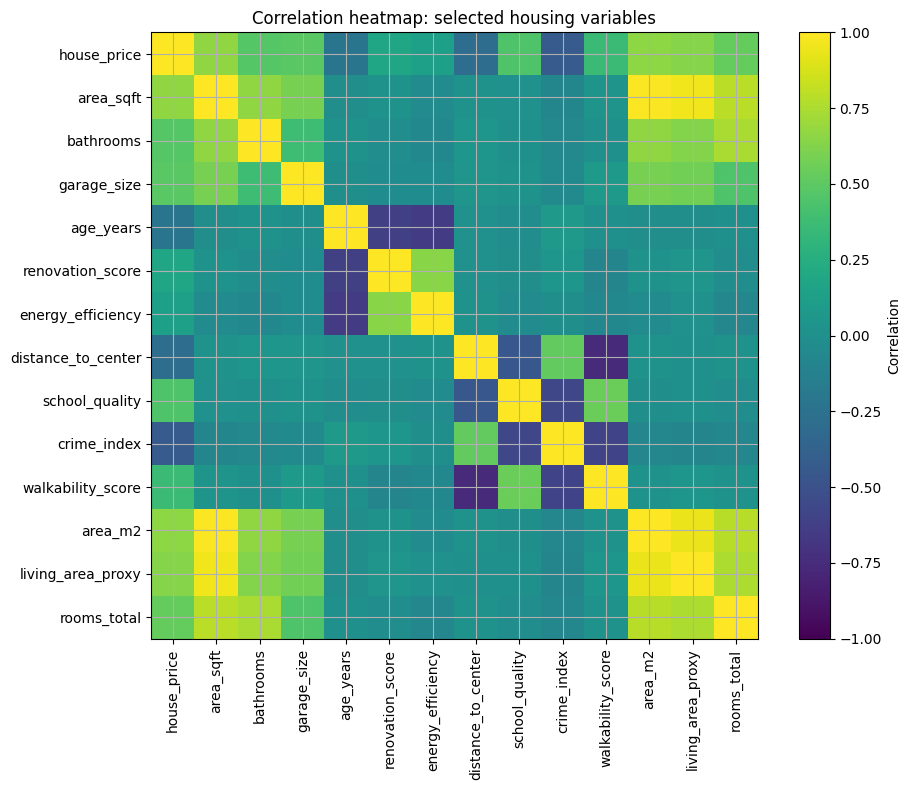

In [5]:
# Correlation heatmap for a subset of numeric features.
# We avoid plotting all variables because the full matrix is too crowded.
subset_cols = [
    "house_price", "area_sqft", "bathrooms", "garage_size", "age_years",
    "renovation_score", "energy_efficiency", "distance_to_center", "school_quality",
    "crime_index", "walkability_score", "area_m2", "living_area_proxy", "rooms_total"
]
corr = housing[subset_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation heatmap: selected housing variables")
plt.tight_layout()
plt.show()

## 1. Mô hình OLS đầy đủ làm mốc so sánh (Full OLS baseline)

Mô hình đầy đủ dùng toàn bộ biến dự báo. Đây là mốc so sánh hữu ích, nhưng có thể khó diễn giải khi nhiều biến là nhiễu hoặc tương quan cao.

### Các thước đo đánh giá mô hình

Giả sử có $n$ quan sát, giá trị thật là $y_i$, giá trị dự đoán là $\hat{y}_i$, trung bình của biến mục tiêu là $\bar{y}$, số biến dự báo là $p$, tổng bình phương sai số là $RSS = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$, và log-likelihood của mô hình là $\log(L)$.

- **MAE (Mean Absolute Error)**:  
  $$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$  
  MAE đo sai số tuyệt đối trung bình, cùng đơn vị với biến mục tiêu. Ví dụ, nếu dự đoán giá nhà sai trung bình 60,000 USD thì `MAE = 60000`. MAE dễ giải thích vì nó trả lời câu hỏi: “trung bình mô hình dự đoán lệch bao nhiêu?”.

- **RMSE (Root Mean Squared Error)**:  
  $$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$  
  RMSE cũng cùng đơn vị với biến mục tiêu, nhưng phạt mạnh các sai số lớn vì sai số được bình phương trước khi lấy căn. Ví dụ, nếu vài căn nhà cao cấp bị dự đoán sai rất nhiều, RMSE sẽ tăng rõ hơn MAE. Vì vậy RMSE hữu ích khi sai số lớn là vấn đề nghiêm trọng.

- **$R^2$ (coefficient of determination)**:  
  $$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2} = 1 - \frac{RSS}{TSS}$$  
  $R^2$ cho biết mô hình giải thích được bao nhiêu phần biến thiên của biến mục tiêu. Ví dụ, `test_R2 = 0.68` nghĩa là mô hình giải thích khoảng 68% biến thiên giá nhà trên tập kiểm tra. $R^2$ cao hơn thường tốt hơn, nhưng nó có thể tăng khi thêm nhiều biến, kể cả biến không thật sự hữu ích.

- **Adjusted $R^2$**:  
  $$Adjusted\ R^2 = 1 - (1 - R^2)\frac{n - 1}{n - p - 1}$$  
  Adjusted $R^2$ điều chỉnh $R^2$ theo số lượng biến dự báo. Nếu thêm biến mới nhưng biến đó không cải thiện mô hình đủ nhiều, Adjusted $R^2$ có thể giảm. Vì vậy nó phù hợp hơn $R^2$ khi so sánh các mô hình có số lượng biến khác nhau.

- **AIC (Akaike Information Criterion)**:  
  $$AIC = 2k - 2\log(L)$$  
  Trong đó $k$ là số tham số ước lượng. AIC cân bằng giữa độ khớp của mô hình và độ phức tạp. Giá trị AIC thấp hơn tốt hơn khi so sánh các mô hình trên cùng dữ liệu. AIC thường ưu tiên mô hình dự đoán tốt, chấp nhận mô hình hơi phức tạp hơn nếu cải thiện độ khớp đáng kể.

- **BIC (Bayesian Information Criterion)**:  
  $$BIC = k\log(n) - 2\log(L)$$  
  BIC tương tự AIC nhưng phạt độ phức tạp mạnh hơn khi số quan sát $n$ tăng. Giá trị BIC thấp hơn tốt hơn. BIC thường chọn mô hình gọn hơn AIC, nên hữu ích khi ta muốn tránh thêm quá nhiều biến không cần thiết.

### So sánh nhanh và lý do cần nhiều thước đo

Không có một thước đo duy nhất trả lời mọi câu hỏi. **MAE** dễ diễn giải bằng đơn vị thực tế; **RMSE** nhạy với sai số lớn; **$R^2$** cho biết mức độ giải thích biến thiên; **Adjusted $R^2$** kiểm tra việc thêm biến có đáng không; **AIC** và **BIC** dùng để so sánh mô hình theo nguyên tắc cân bằng giữa độ khớp và độ phức tạp.

Khi đánh giá mô hình hồi quy, ta thường xem đồng thời train và test metrics. Nếu train tốt nhưng test kém, mô hình có thể đang overfit. Nếu cả train và test đều kém, mô hình có thể thiếu biến quan trọng, quan hệ không tuyến tính, hoặc cần xử lý dữ liệu tốt hơn.

In [6]:
full_model_A, full_metrics_A = evaluate_ols_feature_set(
    X_train_A, y_train_A, X_test_A, y_test_A, list(X_A.columns), "Full OLS"
)
pd.DataFrame([full_metrics_A])

,model,num_features,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,AIC,BIC,Adjusted_R2_train
0,Full OLS,73,45340.127638,71861.347649,35336.299739,60094.670864,0.853468,0.677333,6097.034273,6356.127381,0.790913


In [7]:
# The statsmodels summary contains coefficients, standard errors, t-statistics, p-values, AIC, BIC, and adjusted R^2.
# In a wide dataset, inspect whether many predictors have large p-values and wide confidence intervals.
print(full_model_A.summary())

                            OLS Regression Results                            
Dep. Variable:            house_price   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     13.64
Date:                Thu, 07 May 2026   Prob (F-statistic):           9.48e-44
Time:                        01:18:28   Log-Likelihood:                -2974.5
No. Observations:                 245   AIC:                             6097.
Df Residuals:                     171   BIC:                             6356.
Df Model:                          73                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    2

### Cách đọc bảng `summary()` của statsmodels

Bảng này tóm tắt mô hình OLS đầy đủ. Có thể đọc theo ba phần chính: thông tin tổng quát của mô hình, bảng hệ số, và các kiểm định chẩn đoán ở cuối.

#### 1. Thông tin tổng quát của mô hình

- **Dep. Variable**: biến mục tiêu đang được dự đoán.
- **Model**: loại mô hình; ở đây là `OLS` (Ordinary Least Squares - bình phương tối thiểu thông thường).
- **Method**: cách ước lượng hệ số; ở đây là `Least Squares`, nghĩa là mô hình chọn hệ số để làm nhỏ tổng bình phương sai số.
- **No. Observations**: số dòng dữ liệu dùng để huấn luyện mô hình.
- **Df Residuals**: bậc tự do của phần dư, thường bằng số quan sát trừ số tham số được ước lượng.
- **Df Model**: số biến dự báo trong mô hình, không tính `const`.
- **Covariance Type**: cách ước lượng ma trận hiệp phương sai của hệ số. `nonrobust` là giả định OLS chuẩn, tức sai số có phương sai không đổi và độc lập.

#### 2. Mức độ phù hợp của mô hình

- **R-squared**: tỷ lệ biến thiên của biến mục tiêu được mô hình giải thích. Giá trị càng gần 1 thì mô hình giải thích dữ liệu huấn luyện càng tốt.
- **Adj. R-squared**: R-squared đã điều chỉnh theo số biến dự báo. Chỉ số này hữu ích hơn khi so sánh các mô hình có số lượng biến khác nhau.
- **F-statistic**: kiểm định xem toàn bộ mô hình có hữu ích hay không, tức có ít nhất một hệ số khác 0 hay không.
- **Prob (F-statistic)**: giá trị p cho kiểm định F. Giá trị nhỏ, ví dụ `< 0.05`, cho thấy mô hình tổng thể có ý nghĩa thống kê.
- **Log-Likelihood**: log-likelihood của mô hình; thường dùng để tính AIC và BIC.
- **AIC** và **BIC**: tiêu chí so sánh mô hình. Khi so sánh các mô hình trên cùng dữ liệu, giá trị nhỏ hơn thường tốt hơn. BIC phạt mô hình phức tạp mạnh hơn AIC.

#### 3. Bảng hệ số

Phần này dễ hiểu hơn nếu ta đọc mỗi dòng như một câu hỏi:

> Biến này có thật sự liên quan đến `y` không, hay hệ số ta thấy chỉ là do dữ liệu nhiễu?

Ví dụ một dòng trong bảng có dạng:

| variable | coef | std err | t | P > \|t\| | [0.025 | 0.975] |
| :--- | ---: | ---: | ---: | ---: | ---: | ---: |
| **garage_size** | 23750 | 7079 | 3.354 | 0.001 | 9772 | 37700 |

Ý nghĩa trực giác:

- `coef = 23750`: ước lượng tốt nhất của mô hình là `garage_size` làm giá nhà tăng khoảng 23,750, nếu các biến khác giữ nguyên.
- `std err = 7079`: ước lượng này không chính xác tuyệt đối. Mức sai số điển hình của ước lượng là khoảng 7,079.
- `t = 3.354`: hệ số 23,750 lớn gấp khoảng 3.354 lần sai số chuẩn. Nói cách khác, 23,750 khá xa 0.
- `P>|t| = 0.001`: nếu tác động thật sự của `garage_size` là 0, thì rất khó thấy một kết quả xa 0 như vậy. Vì 0.001 nhỏ hơn 0.05, ta thường xem biến này là có ý nghĩa thống kê.
- `[0.025, 0.975] = [9772, 37700]`: khoảng giá trị hợp lý cho hệ số thật là từ khoảng 9,772 đến 37,700. Vì cả khoảng này đều dương và không chứa 0, kết luận cũng là biến này có ý nghĩa thống kê.

##### Cách đi từ `coef` và `std err` đến `t`

Cột `t` chỉ là tỷ lệ giữa hệ số và độ bất định của hệ số:

$$
t = \frac{coef}{std\ err}
$$

Với ví dụ trên:

$$
t = \frac{23750}{7079} \approx 3.354
$$

Cách hiểu: nếu `coef` là tín hiệu và `std err` là độ nhiễu, thì `t` là tỷ lệ tín hiệu/nhiễu.

- `t` gần 0: tín hiệu nhỏ so với nhiễu.
- `t` lớn dương: hệ số có vẻ dương thật.
- `t` lớn âm: hệ số có vẻ âm thật.

##### Cách tính p-value `P>|t|`

P-value bắt đầu từ giả thuyết tạm thời:

$$
H_0: \text{hệ số thật} = 0
$$

Sau đó ta hỏi:

> Nếu hệ số thật bằng 0, xác suất thấy một giá trị `t` xa 0 như hiện tại là bao nhiêu?

Với ví dụ `t = 3.354`, statsmodels nhìn vào phân phối t với `Df Residuals = 171`. Nó tính xác suất ở hai đuôi:

$$
p\text{-value} = P(T \le -3.354) + P(T \ge 3.354)
$$

Kết quả xấp xỉ `0.001`.

Ta nhân hai phía vì bảng đang kiểm tra cả hai khả năng:

- hệ số thật có thể lớn hơn 0
- hoặc hệ số thật có thể nhỏ hơn 0

Vì vậy tên cột là `P>|t|`: xác suất thấy một giá trị có độ lớn lớn hơn `|t|`.

##### Cách tính khoảng `[0.025, 0.975]`

Khoảng này cũng dùng `coef` và `std err`, nhưng thay vì hỏi “có khác 0 không?”, nó hỏi:

> Hệ số thật có thể nằm trong khoảng nào?

Với khoảng tin cậy 95%, công thức gần đúng là:

$$
coef \pm 2 \times std\ err
$$

Ví dụ:

$$
23750 \pm 2 \times 7079
$$

Tức là khoảng gần đúng:

$$
23750 \pm 14158
$$

nên ta được khoảng khoảng:

$$
[9592, 37908]
$$

Statsmodels dùng giá trị chính xác hơn từ phân phối t, khoảng `1.97` thay vì đúng `2`, nên kết quả trong bảng là gần:

$$
[9772, 37700]
$$

##### Cách đọc nhanh

- Nếu p-value nhỏ hơn `0.05`, biến thường được xem là có ý nghĩa thống kê.
- Nếu khoảng `[0.025, 0.975]` không chứa 0, biến thường cũng có ý nghĩa thống kê.
- Hai cách đọc này gần như nói cùng một điều.
- Nếu khoảng rất rộng, hệ số được ước lượng chưa chắc chắn, dù `coef` nhìn có vẻ lớn.

Ví dụ:

| coef | std err | p-value | confidence interval | Cách đọc |
|---:|---:|---:|---:|---|
| 23750 | 7079 | 0.001 | [9772, 37700] | Có bằng chứng tốt rằng hệ số dương |
| 3000 | 10000 | 0.76 | [-16700, 22700] | Chưa đủ bằng chứng; 0 vẫn là giá trị hợp lý |

Điểm quan trọng nhất: `coef` là ước lượng trung tâm, còn `std err`, `p-value`, và `[0.025, 0.975]` cho ta biết mức độ tin cậy vào ước lượng đó.

#### 4. Các kiểm định chẩn đoán cuối bảng

- **Omnibus** và **Prob(Omnibus)**: kiểm định xem phần dư có phân phối gần chuẩn hay không. Giá trị p nhỏ cho thấy phần dư có thể lệch khỏi phân phối chuẩn.
- **Skew**: độ lệch của phần dư. Giá trị gần 0 nghĩa là phân phối phần dư khá cân bằng.
- **Kurtosis**: độ nhọn/đuôi dày của phân phối phần dư. Với phân phối chuẩn, giá trị thường gần 3.
- **Durbin-Watson**: kiểm tra tự tương quan của phần dư. Giá trị gần 2 là tốt; gần 0 hoặc gần 4 cho thấy có thể có tự tương quan.
- **Jarque-Bera (JB)** và **Prob(JB)**: một kiểm định khác về tính chuẩn của phần dư.
- **Cond. No.**: condition number của ma trận thiết kế. Giá trị rất lớn có thể báo hiệu đa cộng tuyến mạnh hoặc vấn đề về thang đo/numerical stability.

#### 5. Ghi chú quan trọng

Dòng `Standard Errors assume that the covariance matrix of the errors is correctly specified` nghĩa là các sai số chuẩn và giá trị p đang dựa trên giả định OLS chuẩn. Nếu các giả định như phương sai sai số không đổi hoặc độc lập bị vi phạm, các giá trị p và khoảng tin cậy có thể không còn đáng tin cậy.

Nếu `Cond. No.` rất lớn, nên kiểm tra đa cộng tuyến hoặc chuẩn hóa biến số trước khi diễn giải hệ số.

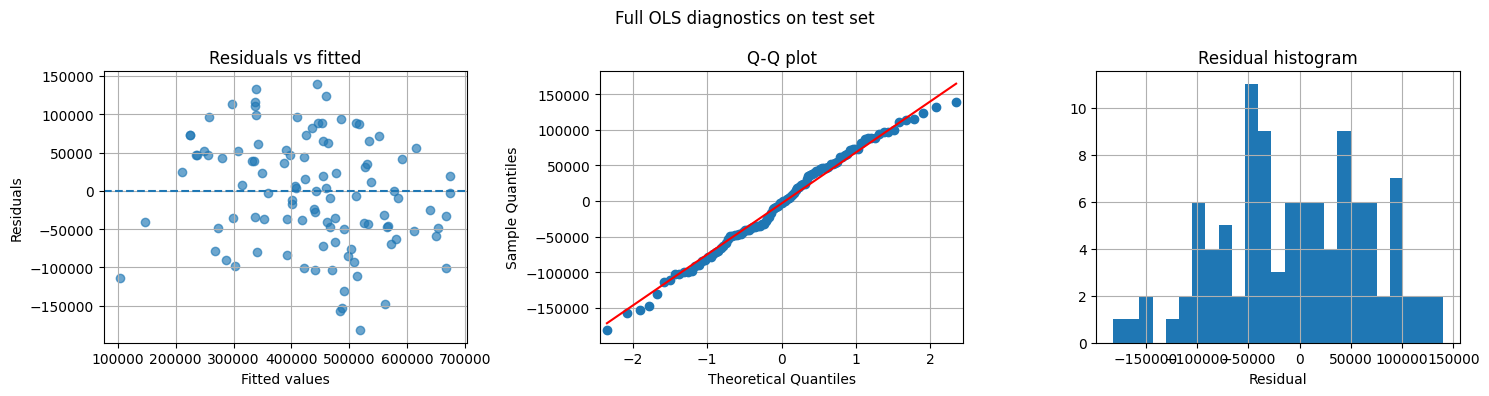

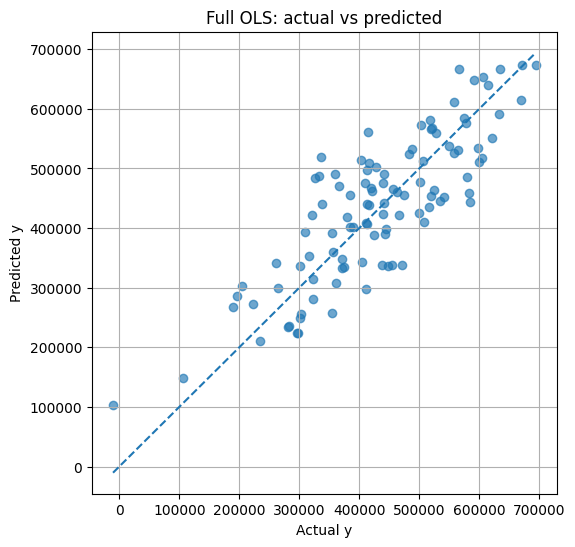

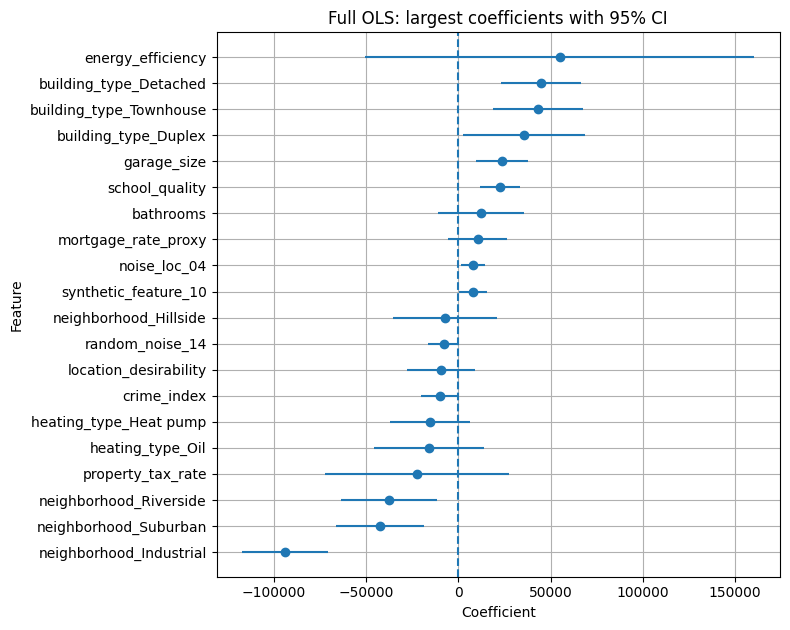

In [8]:
plot_ols_diagnostics(full_model_A, X_test_A, y_test_A, title="Full OLS diagnostics on test set")
plot_actual_vs_predicted(y_test_A, predict_ols(full_model_A, X_test_A), "Full OLS: actual vs predicted")
plot_coefficient_intervals(full_model_A, top_n=20, title="Full OLS: largest coefficients with 95% CI")

## 2. Chọn biến lùi bằng giá trị p (Backward selection using p-values)

Chọn biến lùi bắt đầu từ mô hình đầy đủ và loại biến ít hữu ích nhất về mặt thống kê ở mỗi bước.

Câu hỏi thảo luận: *Việc loại biến có làm giảm RMSE trên tập kiểm tra không, hay chủ yếu giúp mô hình dễ diễn giải hơn?*

In [9]:
backward_features_A, backward_model_A, backward_history_A, backward_metrics_A = backward_selection_pvalue(
    X_train_A, y_train_A, X_test_A, y_test_A, alpha_remove=0.05, verbose=True, max_steps=100
)
print("Selected features:", len(backward_features_A))
backward_features_A[:20]

Step 00: p=73, worst=random_noise_23, p-value=0.9985
Step 01: p=72, worst=synthetic_feature_04, p-value=0.9927
Step 02: p=71, worst=random_noise_13, p-value=0.9841
Step 03: p=70, worst=heating_type_Gas, p-value=0.9757
Step 04: p=69, worst=synthetic_feature_03, p-value=0.9712
Step 05: p=68, worst=synthetic_feature_05, p-value=0.9583
Step 06: p=67, worst=random_noise_24, p-value=0.9280
Step 07: p=66, worst=median_income_area, p-value=0.9267
Step 08: p=65, worst=area_sqft, p-value=0.8991
Step 09: p=64, worst=random_noise_18, p-value=0.8944
Step 10: p=63, worst=random_noise_28, p-value=0.8432
Step 11: p=62, worst=condition_index, p-value=0.8471
Step 12: p=61, worst=random_noise_26, p-value=0.8270
Step 13: p=60, worst=rooms_total, p-value=0.8107
Step 14: p=59, worst=noise_size_06, p-value=0.8072
Step 15: p=58, worst=noise_loc_02, p-value=0.7762
Step 16: p=57, worst=income_proxy, p-value=0.7605
Step 17: p=56, worst=noise_loc_05, p-value=0.7640
Step 18: p=55, worst=lot_size_log, p-value=0.717

['garage_size',
 'age_years',
 'renovation_score',
 'distance_to_center',
 'school_quality',
 'area_m2',
 'noise_loc_04',
 'neighborhood_Industrial',
 'neighborhood_Riverside',
 'neighborhood_Suburban',
 'building_type_Detached']

In [10]:
backward_history_A.tail()

,model,num_features,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,AIC,BIC,Adjusted_R2_train,step,removed_feature,worst_feature,worst_pvalue
58,Backward step,15,50425.696956,67139.811242,40383.952173,54723.171458,0.818752,0.718341,5337.845530,5393.865662,0.806880,58,random_noise_14,random_noise_14,0.054385
59,Backward step,14,50835.705917,65611.984371,40565.884813,53286.768131,0.815793,0.731014,5339.813587,5392.332460,0.804580,59,synthetic_feature_10,synthetic_feature_10,0.074838
60,Backward step,13,51188.407160,65070.601899,40766.521689,52408.305941,0.813228,0.735434,5341.201498,5390.219113,0.802717,60,building_type_Duplex,building_type_Duplex,0.051221
61,Backward step,12,51612.209522,65250.751304,40993.631416,52087.865696,0.810123,0.733968,5343.241636,5388.757992,0.800301,61,building_type_Townhouse,building_type_Townhouse,0.087979
62,Backward step,11,51937.725280,65561.817397,41021.303002,51714.960200,0.807720,0.731425,5344.322338,5386.337436,0.798642,62,NaN,renovation_score,0.015090


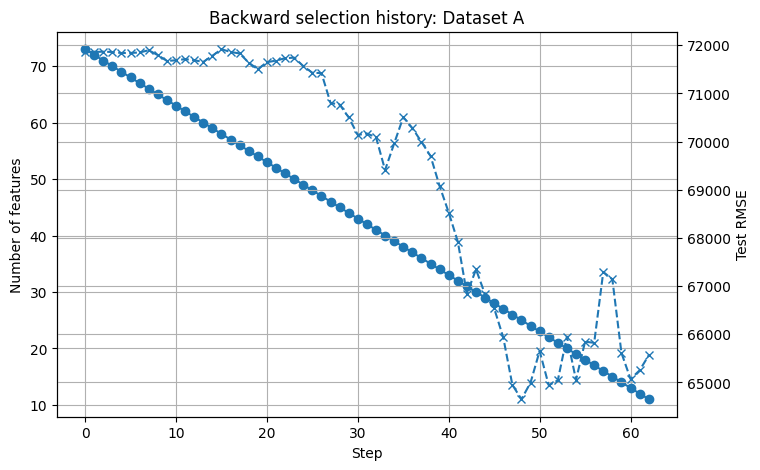

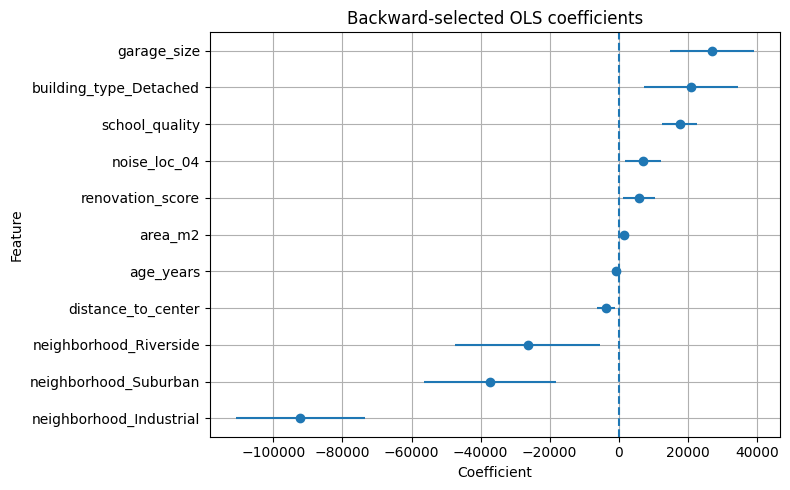

In [11]:

plot_selection_history(backward_history_A, "Backward selection history: Dataset A")
plot_coefficient_intervals(backward_model_A, top_n=20, title="Backward-selected OLS coefficients")


## 3. Chọn biến tiến bằng giá trị p (Forward selection using p-values)

Chọn biến tiến bắt đầu từ mô hình chưa có biến dự báo và thêm biến hữu ích nhất về mặt thống kê ở mỗi bước.

Câu hỏi thảo luận: *Chọn biến tiến có chọn cùng biến với chọn biến lùi không? Vì sao hai phương pháp có thể khác nhau?*

In [12]:
forward_features_A, forward_model_A, forward_history_A, forward_metrics_A = forward_selection_pvalue(
    X_train_A, y_train_A, X_test_A, y_test_A, alpha_enter=0.05, verbose=True, max_features=20
)
print("Selected features:", len(forward_features_A))
forward_features_A[:20]

Step 00: best=area_sqft, p-value=0
Step 01: best=school_quality, p-value=0
Step 02: best=neighborhood_Industrial, p-value=5.329e-15
Step 03: best=condition_index, p-value=9.801e-08
Step 04: best=garage_size, p-value=4.762e-05
Step 05: best=walkability_score, p-value=0.0002334
Step 06: best=neighborhood_Suburban, p-value=0.003661
Step 07: best=building_type_Detached, p-value=0.007982
Step 08: best=neighborhood_Riverside, p-value=0.01424
Step 09: best=noise_loc_04, p-value=0.02588
Step 10: best=building_type_Townhouse, p-value=0.07958
Selected features: 10


['area_sqft',
 'school_quality',
 'neighborhood_Industrial',
 'condition_index',
 'garage_size',
 'walkability_score',
 'neighborhood_Suburban',
 'building_type_Detached',
 'neighborhood_Riverside',
 'noise_loc_04']

In [13]:
forward_history_A

,model,num_features,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,AIC,BIC,Adjusted_R2_train,step,entered_feature,entry_pvalue
0,Forward step,1,87583.468288,96171.201968,69151.089274,74404.384651,0.453220,0.422099,5580.370295,5587.372811,0.450970,0,area_sqft,0.000000e+00
1,Forward step,2,71101.685254,75389.200111,56645.783473,61854.253892,0.639647,0.644874,5480.214496,5490.718271,0.636669,1,school_quality,0.000000e+00
2,Forward step,3,62613.379087,70593.417868,51179.016189,55879.144377,0.720551,0.688619,5419.919786,5433.924819,0.717072,2,neighborhood_Industrial,5.329071e-15
3,Forward step,4,59007.431947,63149.921934,47292.985607,50220.742568,0.751811,0.750822,5392.855153,5410.361444,0.747675,3,condition_index,9.801462e-08
4,Forward step,5,56996.371786,66845.490202,45232.150370,52211.890903,0.768440,0.720805,5377.864017,5398.871566,0.763596,4,garage_size,4.761976e-05
5,Forward step,6,55394.545376,66588.354024,44160.043802,52129.560251,0.781273,0.722949,5365.895840,5390.404648,0.775759,5,walkability_score,2.334397e-04
6,Forward step,7,54414.325867,64766.979871,43378.812595,51836.573276,0.788945,0.737898,5359.147543,5387.157609,0.782712,6,neighborhood_Suburban,3.660773e-03
7,Forward step,8,53607.338043,64290.277247,43276.278364,51257.354072,0.795159,0.741742,5353.826208,5385.337532,0.788215,7,building_type_Detached,7.982040e-03
8,Forward step,9,52925.002386,65199.843820,42309.425702,51944.682224,0.800340,0.734382,5349.549259,5384.561841,0.792694,8,neighborhood_Riverside,1.424134e-02
9,Forward step,10,52365.449028,66237.065583,41593.060795,52558.742611,0.804540,0.725864,5346.341119,5384.854959,0.796187,9,noise_loc_04,2.588466e-02


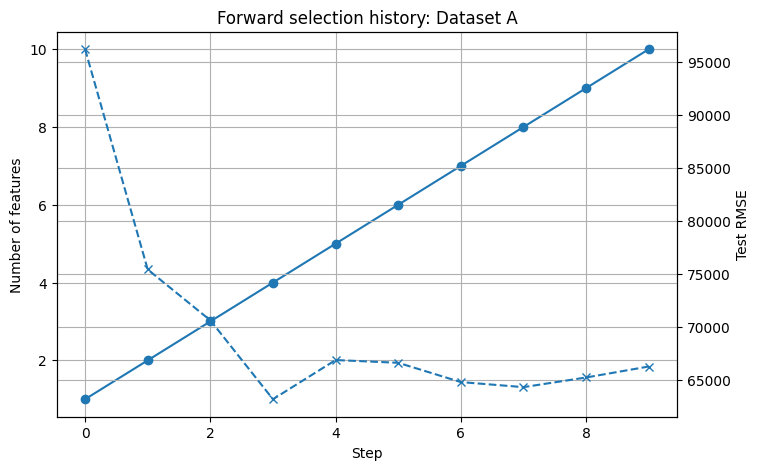

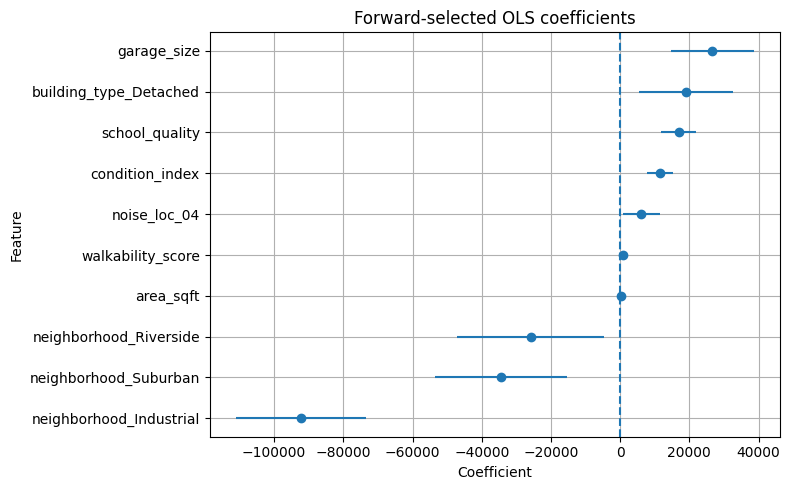

In [14]:
plot_selection_history(forward_history_A, "Forward selection history: Dataset A")
plot_coefficient_intervals(forward_model_A, top_n=20, title="Forward-selected OLS coefficients")

## 4. Chính quy hóa Ridge và Lasso (Ridge and Lasso regularization)

Ridge và Lasso cần chuẩn hóa biến dự báo. Notebook dùng `Pipeline` để việc chuẩn hóa chỉ học từ tập huấn luyện rồi áp dụng cho tập kiểm tra.

In [15]:
ridge_A, lasso_A, reg_metrics_A = fit_regularized_models(X_train_A, y_train_A, X_test_A, y_test_A)
reg_metrics_A

,model,num_features,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,best_alpha
0,Ridge,73,48490.272656,66236.397107,37584.914001,53468.028005,0.832399,0.72587,53.556669
1,Lasso,21,52577.270239,64614.483234,41311.313954,51496.263542,0.802955,0.73913,4237.587161


In [16]:
ridge_coef_A = coefficient_table_from_regularized(ridge_A, X_A.columns, "Ridge")
lasso_coef_A = coefficient_table_from_regularized(lasso_A, X_A.columns, "Lasso")

print("Best Ridge alpha:", ridge_A.named_steps["model"].alpha_)
print("Best Lasso alpha:", lasso_A.named_steps["model"].alpha_)
print("Lasso nonzero features:", (lasso_coef_A["abs_coef"] > 1e-8).sum())

lasso_coef_A.head(20)

Best Ridge alpha: 53.55666917706902
Best Lasso alpha: 4237.587160604064
Lasso nonzero features: 21


,feature,Lasso_coefficient_on_scaled_X,abs_coef
0,area_sqft,38871.462596,38871.462596
64,neighborhood_Industrial,-32452.923227,32452.923227
9,school_quality,26388.491449,26388.491449
16,area_m2,18168.205199,18168.205199
4,garage_size,17550.339504,17550.339504
26,noise_loc_04,8062.551518,8062.551518
5,age_years,-7812.964712,7812.964712
6,renovation_score,7099.067500,7099.067500
66,neighborhood_Suburban,-5917.514733,5917.514733
67,building_type_Detached,5667.170137,5667.170137


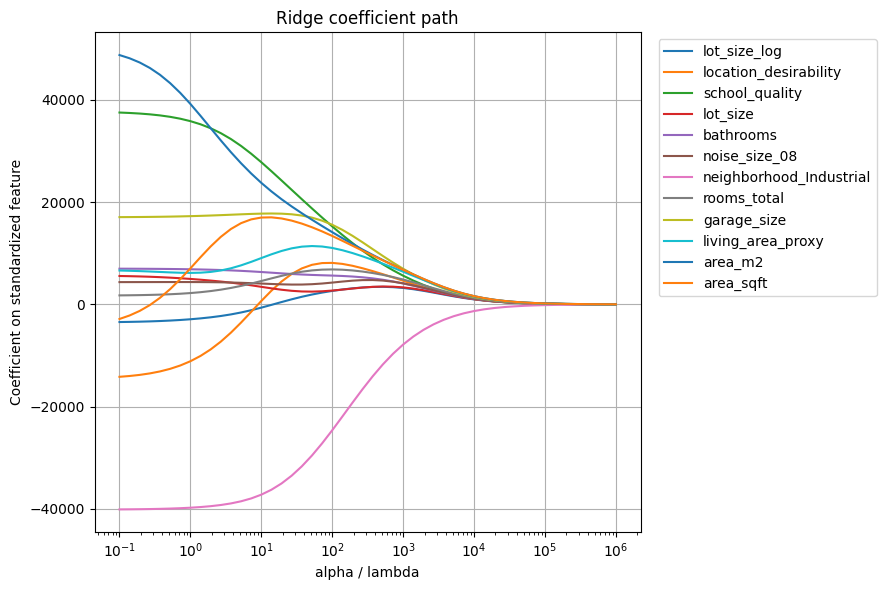

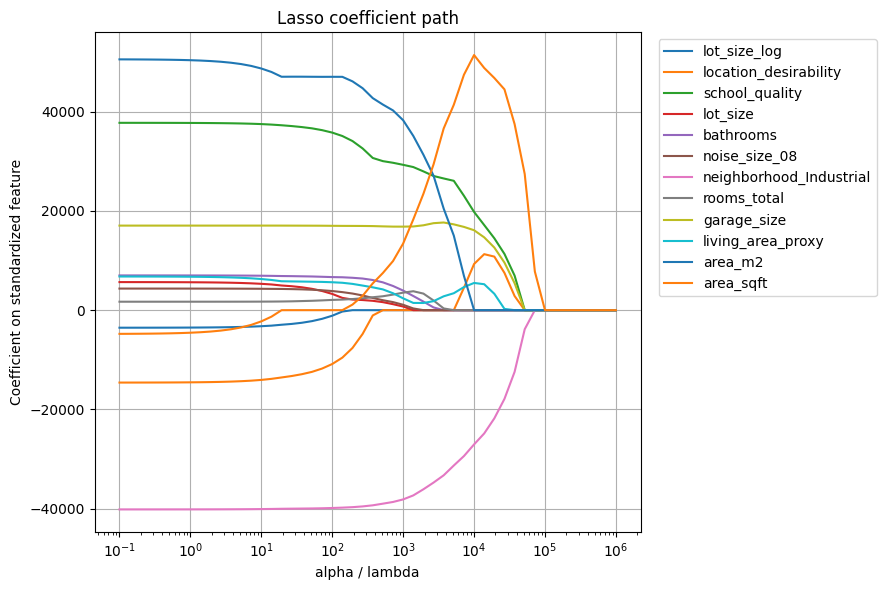

In [17]:
plot_regularization_path(X_train_A, y_train_A, X_A.columns.to_list(), model_type="ridge", top_n=12)
plot_regularization_path(X_train_A, y_train_A, X_A.columns.to_list(), model_type="lasso", top_n=12)

In [18]:
# Compare predictive performance across methods on Dataset A.
comparison_A = pd.concat([
    pd.DataFrame([full_metrics_A, backward_metrics_A, forward_metrics_A]),
    reg_metrics_A
], ignore_index=True)
comparison_A

,model,num_features,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,AIC,BIC,Adjusted_R2_train,best_alpha
0,Full OLS,73,45340.127638,71861.347649,35336.299739,60094.670864,0.853468,0.677333,6097.034273,6356.127381,0.790913,NaN
1,Backward selection,11,51937.725280,65561.817397,41021.303002,51714.960200,0.807720,0.731425,6039.602219,6081.617317,0.798642,NaN
2,Forward selection,10,52365.449028,66237.065583,41593.060795,52558.742611,0.804540,0.725864,6041.621000,6080.134840,0.796187,NaN
3,Ridge,73,48490.272656,66236.397107,37584.914001,53468.028005,0.832399,0.725870,NaN,NaN,NaN,53.556669
4,Lasso,21,52577.270239,64614.483234,41311.313954,51496.263542,0.802955,0.739130,NaN,NaN,NaN,4237.587161


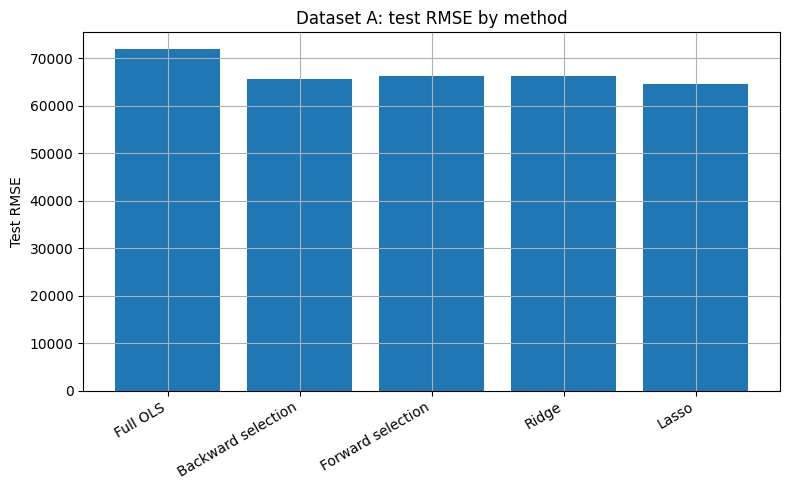

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_A["model"], comparison_A["test_RMSE"])
plt.ylabel("Test RMSE")
plt.title("Dataset A: test RMSE by method")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

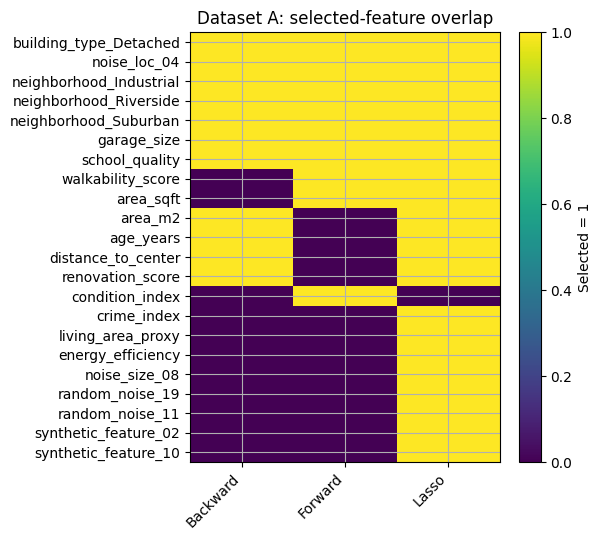

,Backward,Forward,Lasso
building_type_Detached,1,1,1
noise_loc_04,1,1,1
neighborhood_Industrial,1,1,1
neighborhood_Riverside,1,1,1
neighborhood_Suburban,1,1,1
garage_size,1,1,1
school_quality,1,1,1
walkability_score,0,1,1
area_sqft,0,1,1
area_m2,1,0,1


In [20]:
lasso_features_A = lasso_coef_A.query("abs_coef > 1e-8")["feature"].tolist()
overlap_A = plot_feature_overlap({
    "Backward": backward_features_A,
    "Forward": forward_features_A,
    "Lasso": lasso_features_A,
}, title="Dataset A: selected-feature overlap")
overlap_A.head(30)

## 5. So sánh suy luận thống kê (Statistical inference comparison)

Với mô hình OLS, sai số chuẩn (standard errors) và khoảng tin cậy (confidence intervals) được tính từ:

$$
\widehat{Var}(\hat{\beta}) = \hat{\sigma}^2 (X^T X)^{-1}
$$

Với Ridge/Lasso, giá trị p cổ điển không có trực tiếp vì hệ số đã bị phạt. Ta dùng khoảng bootstrap như một cách khám phá độ ổn định của hệ số.

In [21]:
# Inference table for full OLS, backward-selected OLS, and forward-selected OLS.
# Reminder: p-values after forward/backward selection are post-selection p-values.
# They are useful for exploration, but they are usually too optimistic for formal claims.

def compact_inference(model, label, top_n=12):
    tbl = model.summary2().tables[1].reset_index().rename(columns={"index": "feature"})
    tbl["model"] = label
    tbl["abs_coef"] = tbl["Coef."].abs()
    return tbl.sort_values("abs_coef", ascending=False).head(top_n)

inference_A = pd.concat([
    compact_inference(full_model_A, "Full OLS"),
    compact_inference(backward_model_A, "Backward OLS"),
    compact_inference(forward_model_A, "Forward OLS"),
], ignore_index=True)
inference_A

,feature,Coef.,Std.Err.,t,P>|t|,[0.025,0.975],model,abs_coef
0,neighborhood_Industrial,-93847.616976,11775.834127,-7.969509,2.156879e-13,-117092.335797,-70602.898156,Full OLS,93847.616976
1,energy_efficiency,55046.244087,53374.245096,1.031326,3.038445e-01,-50310.990583,160403.478756,Full OLS,55046.244087
2,building_type_Detached,44816.258329,10942.343632,4.095673,6.484732e-05,23216.794698,66415.721961,Full OLS,44816.258329
3,building_type_Townhouse,43297.363796,12396.461822,3.492719,6.086316e-04,18827.566895,67767.160697,Full OLS,43297.363796
4,neighborhood_Suburban,-42474.201612,12006.345846,-3.537646,5.198432e-04,-66173.935343,-18774.467881,Full OLS,42474.201612
5,neighborhood_Riverside,-37441.552354,13244.750030,-2.826898,5.260822e-03,-63585.814153,-11297.290556,Full OLS,37441.552354
6,building_type_Duplex,35546.757877,16665.910859,2.132902,3.435941e-02,2649.350555,68444.165198,Full OLS,35546.757877
7,const,26007.901807,190792.004500,0.136315,8.917322e-01,-350602.914048,402618.717662,Full OLS,26007.901807
8,garage_size,23745.997632,7079.067486,3.354396,9.796651e-04,9772.385958,37719.609306,Full OLS,23745.997632
9,school_quality,22595.453666,5521.213206,4.092480,6.566579e-05,11696.943451,33493.963881,Full OLS,22595.453666


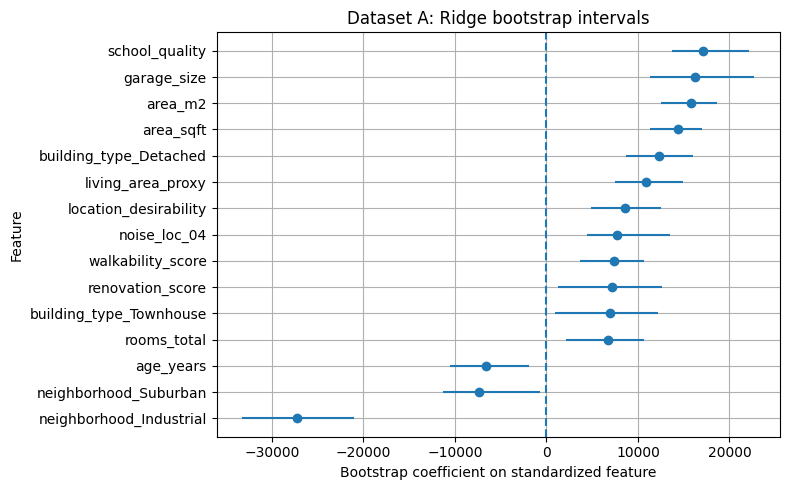

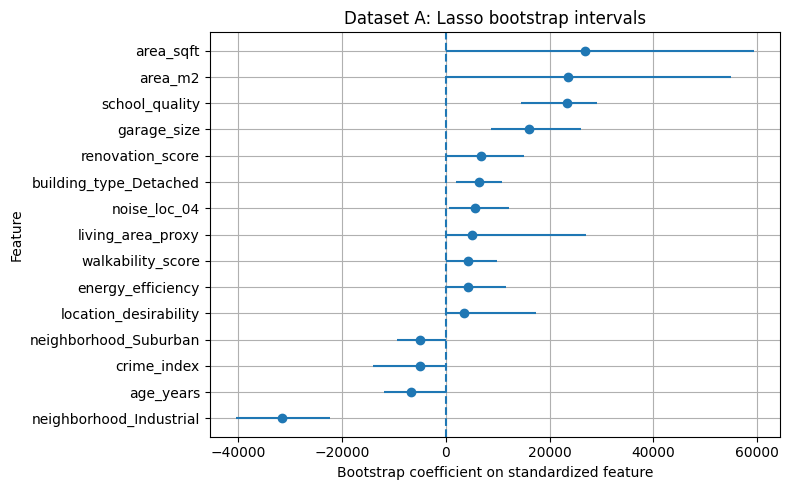

,feature,boot_mean,boot_low_2_5,boot_high_97_5,selection_frequency,abs_mean
64,neighborhood_Industrial,-31505.613315,-40465.534692,-22218.366600,1.000000,31505.613315
0,area_sqft,26896.592054,0.000000,59385.865780,0.766667,26896.592054
16,area_m2,23497.514846,0.000000,54919.746036,0.866667,23497.514846
9,school_quality,23295.375813,14506.223113,29218.735616,1.000000,23295.375813
4,garage_size,16136.640613,8716.594477,26038.932490,1.000000,16136.640613
6,renovation_score,6797.684197,0.000000,15167.229376,0.833333,6797.684197
5,age_years,-6622.084947,-11943.554377,0.000000,0.866667,6622.084947
67,building_type_Detached,6337.181855,2013.533855,10918.156145,1.000000,6337.181855
26,noise_loc_04,5605.818693,558.209441,12171.931084,0.966667,5605.818693
10,crime_index,-5021.654037,-13913.202841,0.000000,0.766667,5021.654037


In [22]:
# Bootstrap Ridge and Lasso coefficients.
# Increase n_boot for a more stable assignment result; keep it small in class if runtime matters.
ridge_boot_A, ridge_boot_summary_A = bootstrap_regularized_coefficients(
    X_train_A, y_train_A, X_A.columns.to_list(), "ridge", ridge_A.named_steps["model"].alpha_, n_boot=30
)
lasso_boot_A, lasso_boot_summary_A = bootstrap_regularized_coefficients(
    X_train_A, y_train_A, X_A.columns.to_list(), "lasso", lasso_A.named_steps["model"].alpha_, n_boot=30
)

plot_bootstrap_intervals(ridge_boot_summary_A, top_n=15, title="Dataset A: Ridge bootstrap intervals")
plot_bootstrap_intervals(lasso_boot_summary_A, top_n=15, title="Dataset A: Lasso bootstrap intervals")

lasso_boot_summary_A.head(20)

## 6. Tùy chọn: Fit lại OLS sau khi Lasso chọn biến (Refit OLS after Lasso selection)

Một quy trình khám phá thường dùng là:

1. Dùng Lasso để chọn biến.
2. Fit lại OLS chỉ với các biến được chọn.
3. Xem hệ số OLS và khoảng tin cậy.

Cách này hữu ích để giảng dạy, nhưng **không hoàn toàn hợp lệ cho suy luận sau chọn biến (post-selection inference)**.

                            OLS Regression Results                            
Dep. Variable:            house_price   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     48.13
Date:                Thu, 07 May 2026   Prob (F-statistic):           8.62e-71
Time:                        01:18:37   Log-Likelihood:                -3000.2
No. Observations:                 245   AIC:                             6044.
Df Residuals:                     223   BIC:                             6121.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    8

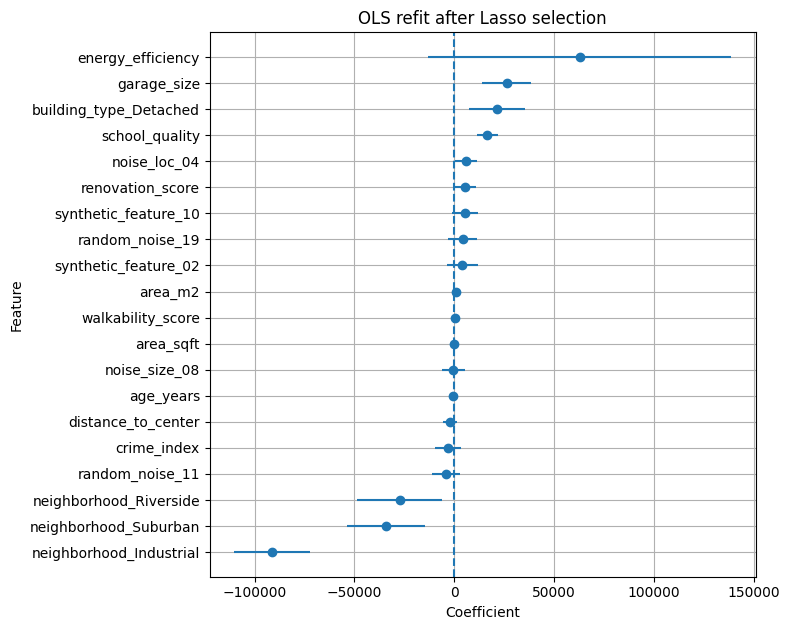

In [23]:
if len(lasso_features_A) > 0:
    lasso_refit_A, lasso_refit_metrics_A = evaluate_ols_feature_set(
        X_train_A, y_train_A, X_test_A, y_test_A, lasso_features_A, "Lasso-selected then OLS refit"
    )
    print(lasso_refit_A.summary())
    plot_coefficient_intervals(lasso_refit_A, top_n=20, title="OLS refit after Lasso selection")
else:
    print("Lasso selected no features at the current alpha.")

# Phần B: Lặp lại với bộ dữ liệu doanh số marketing (Marketing Sales Dataset)

Bộ dữ liệu B có ít biến hơn và bối cảnh kinh doanh khác. Mục tiêu là xem thứ hạng các phương pháp có thay đổi khi dữ liệu không quá rộng hay không.

In [24]:
results_B = run_complete_suite("dataset_B_marketing_sales.csv", target="monthly_sales", verbose=False)
results_B["comparison"]

,model,num_features,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,AIC,BIC,Adjusted_R2_train,best_alpha
0,Full OLS,31,38593.425845,40718.978490,31190.231119,32265.463257,0.855656,0.840517,8449.843031,8573.296892,0.841585,NaN
1,Backward selection,7,39669.514954,40926.324465,31776.493448,32415.741363,0.847495,0.838889,8421.093774,8451.957239,0.844373,NaN
2,Forward selection,7,39669.514954,40926.324465,31776.493448,32415.741363,0.847495,0.838889,8421.093774,8451.957239,0.844373,NaN
3,Ridge,31,38751.144909,40877.183282,31243.716547,32180.072443,0.854474,0.839276,NaN,NaN,NaN,13.664483
4,Lasso,15,39290.204647,40263.446258,31493.476044,31663.634527,0.850397,0.844066,NaN,NaN,NaN,1867.181091


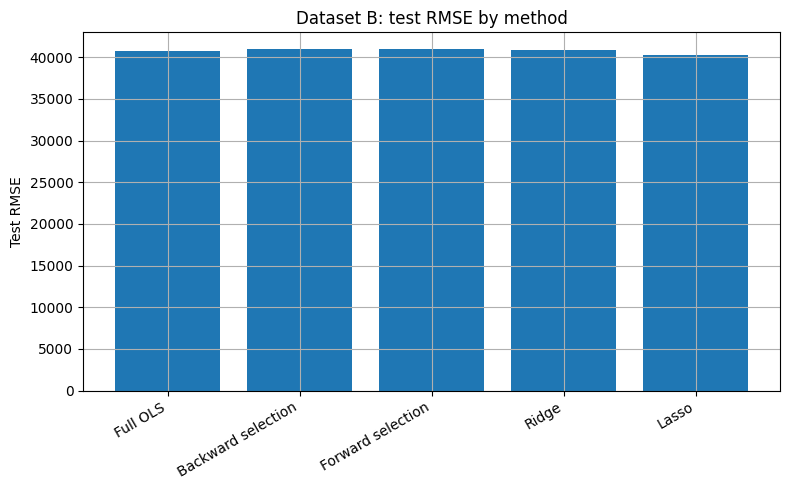

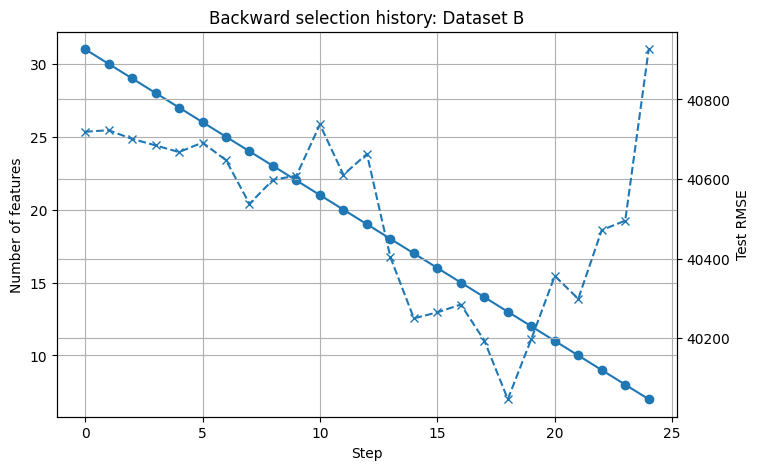

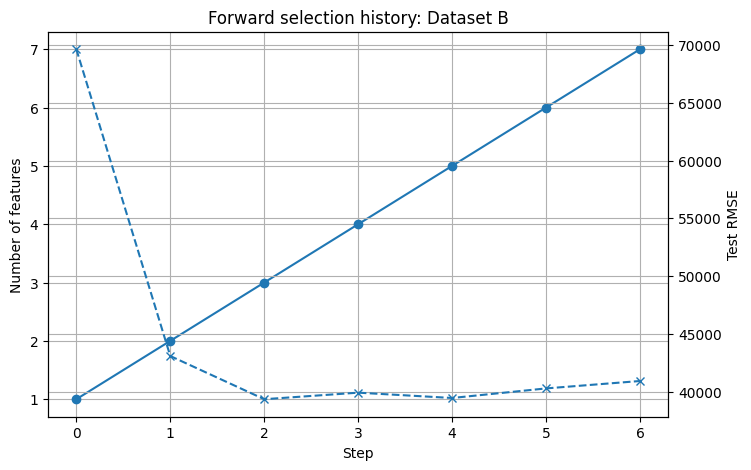

In [25]:
# Visualize Dataset B method comparison.
comparison_B = results_B["comparison"]
plt.figure(figsize=(8, 5))
plt.bar(comparison_B["model"], comparison_B["test_RMSE"])
plt.ylabel("Test RMSE")
plt.title("Dataset B: test RMSE by method")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plot_selection_history(results_B["backward_history"], "Backward selection history: Dataset B")
plot_selection_history(results_B["forward_history"], "Forward selection history: Dataset B")

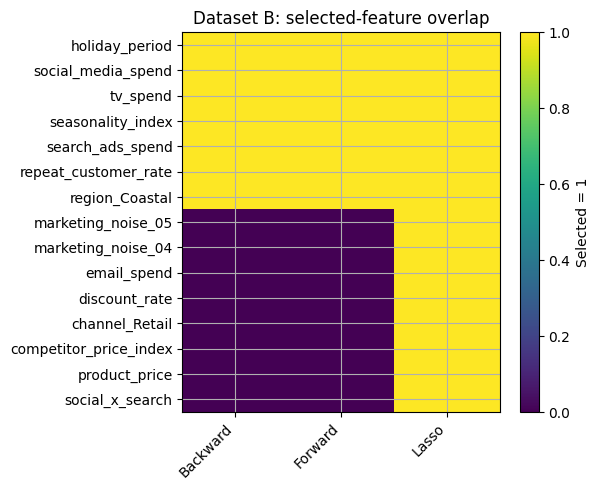

,Backward,Forward,Lasso
holiday_period,1,1,1
social_media_spend,1,1,1
tv_spend,1,1,1
seasonality_index,1,1,1
search_ads_spend,1,1,1
repeat_customer_rate,1,1,1
region_Coastal,1,1,1
marketing_noise_05,0,0,1
marketing_noise_04,0,0,1
email_spend,0,0,1


In [26]:
# Feature overlap for Dataset B
lasso_features_B = results_B["lasso_features"]
overlap_B = plot_feature_overlap({
    "Backward": results_B["backward_features"],
    "Forward": results_B["forward_features"],
    "Lasso": lasso_features_B,
}, title="Dataset B: selected-feature overlap")
overlap_B.head(30)

# Phản tư cuối bài dành cho sinh viên

Hãy trả lời các câu hỏi sau:

1. Mô hình nào có RMSE trên tập kiểm tra thấp nhất đối với Dataset A? Đối với Dataset B?
2. Mô hình nào dễ diễn giải nhất?
3. Phương pháp chọn biến lùi (backward) và tiến (forward) có chọn cùng một tập biến không?
4. Lasso có chọn các biến tương tự như các phương pháp dựa trên p-value không?
5. Ridge có cải thiện khả năng dự đoán mà không làm đơn giản hóa danh sách đặc trưng không?
6. Điều gì khiến việc suy luận (inference) sau khi chọn đặc trưng trở nên khó khăn?
7. Nếu mục tiêu là dự đoán, bạn sẽ chọn mô hình nào?
8. Nếu mục tiêu là giải thích, bạn sẽ chọn mô hình nào?
9. Những trực quan hóa nào hữu ích nhất cho việc diễn giải?